# Chokepoint Disruption in the Global Oil Network
## CITS4403 Computational Modelling — Raed

**System.** The Strait of Hormuz carries ~20 mb/d of oil, about 20% of global
petroleum liquids consumption. Its 2026 closure was the largest supply
disruption in the history of the oil market.

**Research question.**
> As the fraction of Hormuz flow blocked increases, is there a **critical
> closure level** at which localised shortfall becomes systemic production
> failure — and which real intervention (strategic reserve release, demand
> reduction, bypass capacity) most raises that threshold?

**Why it is a complex system.** Losing the chokepoint does not simply subtract
barrels. Flows reroute until bypass pipelines and canals reach their limits; regions compete
for scarce substitute crude; price rises destroy demand while shortage fear
drives hoarding; and shortfalls propagate downstream through production
sectors. These interactions produce behaviour that subtraction cannot predict.

**Calibration.** Every parameter comes from published data (EIA, IEA, DOE,
S&P Platts, OGJ, Cooper 2003) — see `data/DATA_AND_SOURCES.md`.

**How to run.** `pip install -r requirements.txt`, then run all cells.
Total runtime about 10–15 minutes (the closure grid and intervention comparison are
the slow parts).

## 0. Setup

In [1]:
import sys, os                                    # system paths and folders
sys.path.insert(0, os.path.join('..', 'utils'))   # let Python find the utils/ folder
from paths import add_src_to_path, figures_dir    # two small helpers from utils/paths.py
add_src_to_path()                                 # let Python find the model files in src/
FIG = figures_dir()                               # the folder where every figure is saved

import numpy as np                                # maths
import matplotlib.pyplot as plt                   # charts
import networkx as nx                             # graphs (from the lectures)

from oil_model_data import *                      # every number the model uses

# What the model actually runs on - every value below is read by the model code.
prod, cons = sum(PRODUCTION_BY_REGION.values()), sum(CONSUMPTION_BY_REGION.values())   # world totals, mb/d
hz = CHOKEPOINTS["Hormuz"][0]                     # Hormuz normal flow (EIA 2023)
print(f"World            {prod:.1f} mb/d produced, {cons:.1f} mb/d consumed, {len(CONSUMPTION_BY_REGION)} regions")
print(f"Hormuz           {hz} mb/d normal flow (EIA 2023) = {hz/cons:.0%} of the modelled system")
print(f"Bypass pipelines Saudi East-West {SAUDI_EASTWEST_CAPACITY} + UAE ADCOP {ADCOP_CAPACITY} = {SAUDI_EASTWEST_CAPACITY+ADCOP_CAPACITY} mb/d")
print(f"Chokepoints      {len(CHOKEPOINTS)}: " + ", ".join(CHOKEPOINTS))
print()
print("Strategic reserves (each region draws only on its own):")
for r, mb in sorted(REGIONAL_RESERVES.items(), key=lambda x: -x[1]):   # largest reserve first
    if mb > 0:                                                         # skip regions with none
        print(f"  {r:<11}{mb:7.0f} Mb   max draw {REGIONAL_DRAW_RATE[r]:.1f} mb/d")
print(f"  {'TOTAL':<11}{sum(REGIONAL_RESERVES.values()):7.0f} Mb")

World            105.3 mb/d produced, 102.0 mb/d consumed, 10 regions
Hormuz           20.9 mb/d normal flow (EIA 2023) = 20% of the modelled system
Bypass pipelines Saudi East-West 7.0 + UAE ADCOP 1.5 = 8.5 mb/d
Chokepoints      8: Hormuz, Malacca, Bab el-Mandeb, Cape of Good Hope, Danish Straits, Turkish Straits, Suez+SUMED, Panama

Strategic reserves (each region draws only on its own):
  China         1400 Mb   max draw 4.0 mb/d
  JapanKorea     449 Mb   max draw 2.0 mb/d
  NAmerica       285 Mb   max draw 2.7 mb/d
  Europe         179 Mb   max draw 1.5 mb/d
  OtherAsia       50 Mb   max draw 0.3 mb/d
  India           39 Mb   max draw 0.5 mb/d
  TOTAL         2402 Mb


## 0b. Model correctness and boundary-case tests

Before presenting any results, we verify the model behaves correctly. The test
suite (`src/test_model.py`) checks four categories:

1. **Conservation** — nothing is created or destroyed incorrectly (deliveries
   never exceed demand or supply; no pipeline, canal or route carries more than its capacity)
2. **Boundary cases** — behaviour at the extremes (strait fully open, fully
   closed, empty reserve, zero and full supply to the production cascade)
3. **Monotonicity** — the model responds in the expected direction (more
   closure causes more damage; a reserve reduces peak price)
4. **Exceptional inputs** — degenerate cases do not crash or produce NaN
   (zero-length runs, near-zero elasticity, a second chokepoint closure)

In [2]:
import subprocess, sys, os                                       # to run another Python file
src_dir = os.path.join('..', 'src')                             # where test_model.py lives
res = subprocess.run([sys.executable, 'test_model.py'], cwd=src_dir,   # run the test file, exactly as from a terminal
                     capture_output=True, text=True)            # and capture what it prints
print(res.stdout)                                               # show everything the test file printed
if res.returncode != 0:                                         # if the test file itself crashed...
    print(res.stderr)                                           # ...show the error message too

MODEL CORRECTNESS AND BOUNDARY-CASE TESTS

1. CONSERVATION CHECKS
  [PASS] delivered <= demand for every region
  [PASS] no canal exceeds its capacity  — all within capacity
  [PASS] no route or pipeline exceeds its own capacity  — all within capacity
  [PASS] total delivered <= total supply  — 102.0 <= 105.3
  [PASS] unserved demand is never negative

2. BOUNDARY CASES
  [PASS] fully open strait: unserved is near zero  — 0.00 mb/d
  [PASS] fully closed strait: unserved <= total demand  — 12.8 <= 102.0
  [PASS] fully closed causes more damage than fully open
  [PASS] closed strait carries zero flow
  [PASS] reserves drain to zero and never below  — 2 regions emptied, lowest total 913 Mb
  [PASS] reserves empty on the day volume / rate predicts  — OtherAsia day 167, China day 350
  [PASS] price index never drops below 1.0 (guard on the clip)
  [PASS] operability(0) == 0
  [PASS] operability(1) ~ 1
  [PASS] operability is monotonic in input
  [PASS] full supply -> no systemic loss  — 0.0

## 1. The model

**Entities.** Ten world regions — North America, Latin America, Europe, CIS,
Middle East, Africa, China, India, Japan/Korea and Other Asia — each both
producing and consuming oil, on a consistent total-liquids basis (~105 mb/d
produced, ~102 mb/d consumed), with East Siberian
production as an eleventh, export-only node. They are linked by 37 maritime and pipeline
routes passing through eight real chokepoints. Open sea straits have no throughput limit,
only a normal flow; pipelines and canals (Suez, Panama) have a capacity.

**Mechanisms.**
1. **Domestic first** — each region consumes its own production before anything
   is traded. Domestic oil can never be bid away.
2. **Congestion cascade** — exports fill the fastest routes first; when a
   pipeline or canal reaches its limit, traffic spills onto slower alternatives.
3. **Two-stage allocation** — contracted exports go by route speed; spot exports
   go to the highest *netback* (scarcity premium minus freight cost). In practice
   freight is small next to differences in scarcity, so the most desperate buyer is
   served first.
4. **Bypass pipelines** — the Saudi East-West line (7.0 mb/d) and UAE ADCOP
   (1.5 mb/d) each share one throughput budget across their legs.
5. **Price equilibrium** — constant-elasticity demand; price rises until demand
   destruction closes the gap.
6. **Regional strategic reserves** — each region draws only on its own stocks.
7. **Production cascade** — shortfalls propagate through economic sectors via
   operability bands.

Hoarding and refinery redistribution friction are implemented but **disabled by
default** — see the limitations in section 10.

In [3]:
from oil_network_model import OilNetworkModel, ROUTES, REGION_DEMAND, ORIGIN_SUPPLY   # the model and its network

print(f"Routes: {len(ROUTES)}   Chokepoints: {len(CHOKEPOINTS)}\n")
print("Demand (mb/d):", {k: round(v, 1) for k, v in REGION_DEMAND.items()})     # what each region needs
print("Supply (mb/d):", {k: round(v, 1) for k, v in ORIGIN_SUPPLY.items()})     # what each producer node has
print()
print(f"{'route':<24}{'from':<11}{'to':<12}{'days':>5}  {'limit':>6}   via")   # every edge of the network
for name, (origin, dest, via, days, limit) in sorted(ROUTES.items(), key=lambda x: x[1][3]):   # shortest voyage first
    lim = "-" if limit is None else f"{limit:.1f}"                                 # "-" = the route has no limit of its own
    pipe = " (shares a pipeline budget)" if name.startswith(("SaudiPipe", "ADCOP")) else ""
    print(f"{name:<24}{origin.replace('_P', ''):<11}{dest:<12}{days:>5}  {lim:>6}   "
          f"{', '.join(via) if via else '(direct)'}{pipe}")

Routes: 37   Chokepoints: 8

Demand (mb/d): {'NAmerica': 24.6, 'LatAm': 6.5, 'Europe': 14.5, 'CIS': 4.8, 'MidEast': 9.5, 'Africa': 4.4, 'China': 16.4, 'India': 5.6, 'JapanKorea': 5.7, 'OtherAsia': 10.0}
Supply (mb/d): {'NAmerica_P': 31.1, 'LatAm_P': 8.4, 'Europe_P': 4.0, 'CIS_P': 12.0, 'MidEast_P': 31.0, 'Africa_P': 7.6, 'China_P': 5.3, 'India_P': 0.9, 'JapanKorea_P': 0.1, 'OtherAsia_P': 3.1, 'CISEast_P': 1.8}

route                   from       to           days   limit   via
CIS->Europe (Baltic)    CIS        Europe          5     2.5   Danish Straits
ME->India               MidEast    India           6       -   Hormuz
ADCOP->India            MidEast    India           6       -   (direct) (shares a pipeline budget)
CISEast->JapanKorea     CISEast    JapanKorea      6       -   (direct)
NA->LatAm               NAmerica   LatAm           6       -   (direct)
CIS->Europe (BlackSea)  CIS        Europe          7       -   Turkish Straits
LA->NAmerica            LatAm      NAmerica     

### Layers 2 and 3 as networks

Layer 1 is the route network drawn in section 1b. Layers 2 and 3 are networks too:
Layer 2 links every region to one world price (edges labelled with each region's price
elasticity), with each strategic reserve attached only to its own region. Layer 3 is the
same five-sector network inside every region: oil feeds each sector, and sectors supply
each other.

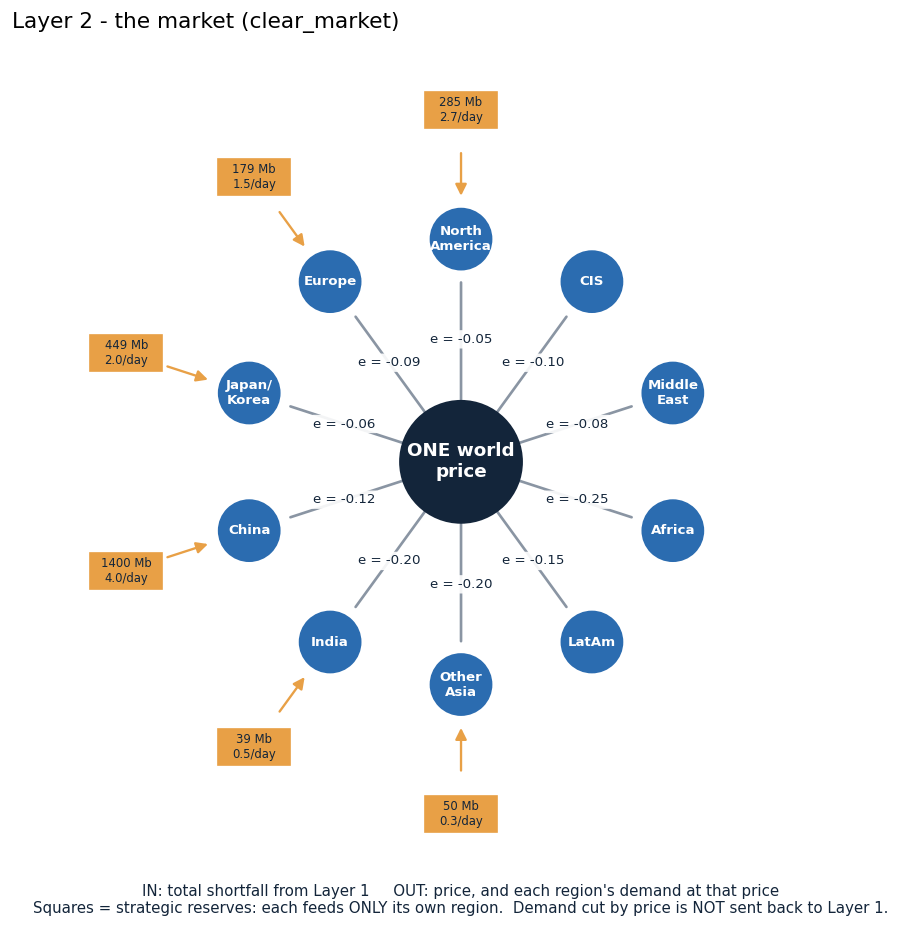

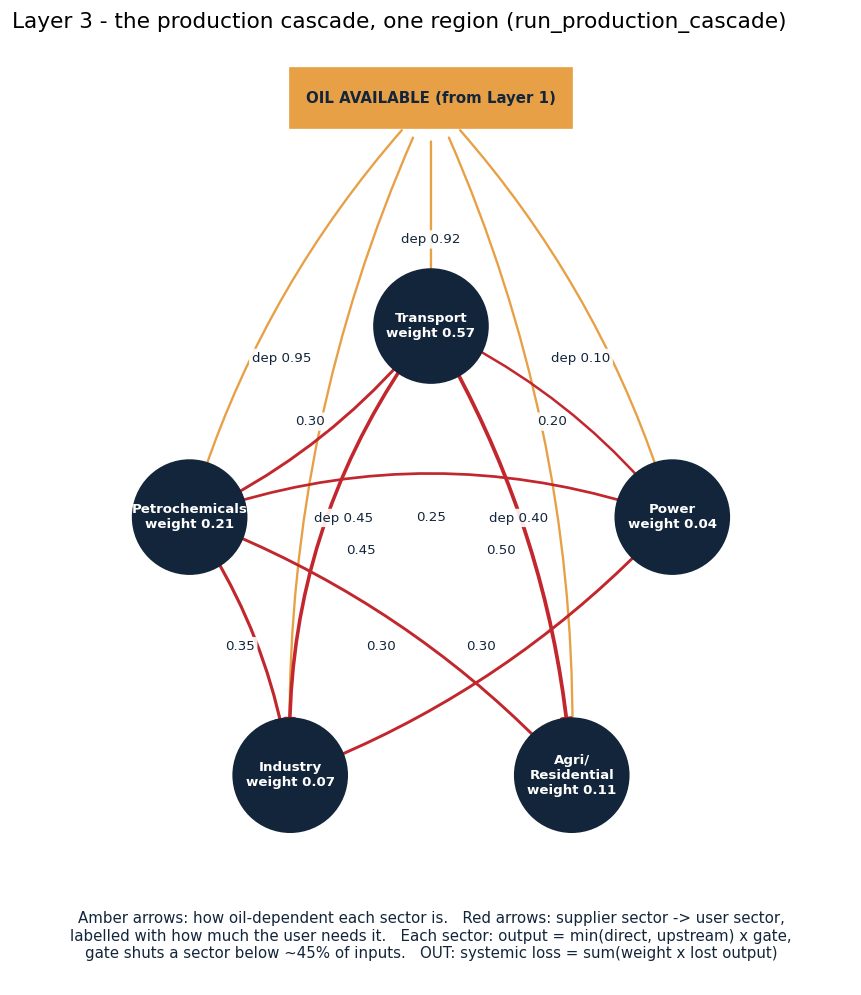

In [4]:
from layer_diagrams import draw_all                 # draws both diagrams into figures/
from IPython.display import Image, display
for p in draw_all(out=FIG):
    display(Image(p))                              # show each one here

## 1b. The network, node by node

Every node and edge, with its value, for two scenarios: normal conditions and the
observed Q2 2026 closure (Hormuz 77% blocked).

- **Regions** (consumer nodes): production, demand, how much comes from home
  production versus imports, and what share of demand is met.
- **Chokepoints** (passage nodes): flow, and how it compares with normal. Straits have no
  capacity; canals do.
- **Routes** (edges): the oil each route carries. Only routes carrying oil are listed.

The map draws the same numbers: line width is flow, and a route's flow is added onto
every segment of its path, so a thick line means several routes crowd through it.

In [5]:
from network_view import snapshot, print_tables, draw    # tables and maps of the network

normal = snapshot(1.0)          # RUN the model: Hormuz fully open (1.0 = 100% open), 150 days
q2     = snapshot(4.9 / 20.9)   # RUN again: Hormuz 23% open, as observed in Q2 2026

print("=" * 25, "NORMAL: Hormuz open", "=" * 25)
print_tables(normal)            # regions, chokepoints and routes for the normal case
print()
print("=" * 20, "Q2 2026: Hormuz 77% blocked", "=" * 20)
print_tables(q2)                # the same tables under the Q2 2026 closure

========================= NORMAL: Hormuz open =========================
REGIONS (consumer nodes), mb/d  -  BEFORE any reserve release
region       produce consume domestic  import reserve    got  short   met reserve left
NAmerica        31.1    24.6     24.6     0.0     0.0   24.6   0.00  100%       285 Mb
LatAm            8.4     6.5      6.5     0.0     0.0    6.5   0.00  100%         0 Mb
Europe           4.0    14.5      4.0    10.5     0.0   14.5   0.00  100%       179 Mb
CIS             13.8     4.8      4.8     0.0     0.0    4.8   0.00  100%         0 Mb
MidEast         31.0     9.5      9.5     0.0     0.0    9.5   0.00  100%         0 Mb
Africa           7.6     4.4      4.4     0.0     0.0    4.4   0.00  100%         0 Mb
China            5.3    16.4      5.3    11.1     0.0   16.4   0.00  100%      1400 Mb
India            0.9     5.6      0.9     4.7     0.0    5.6   0.00  100%        39 Mb
JapanKorea       0.1     5.7      0.1     5.6     0.0    5.7   0.00  100%       449

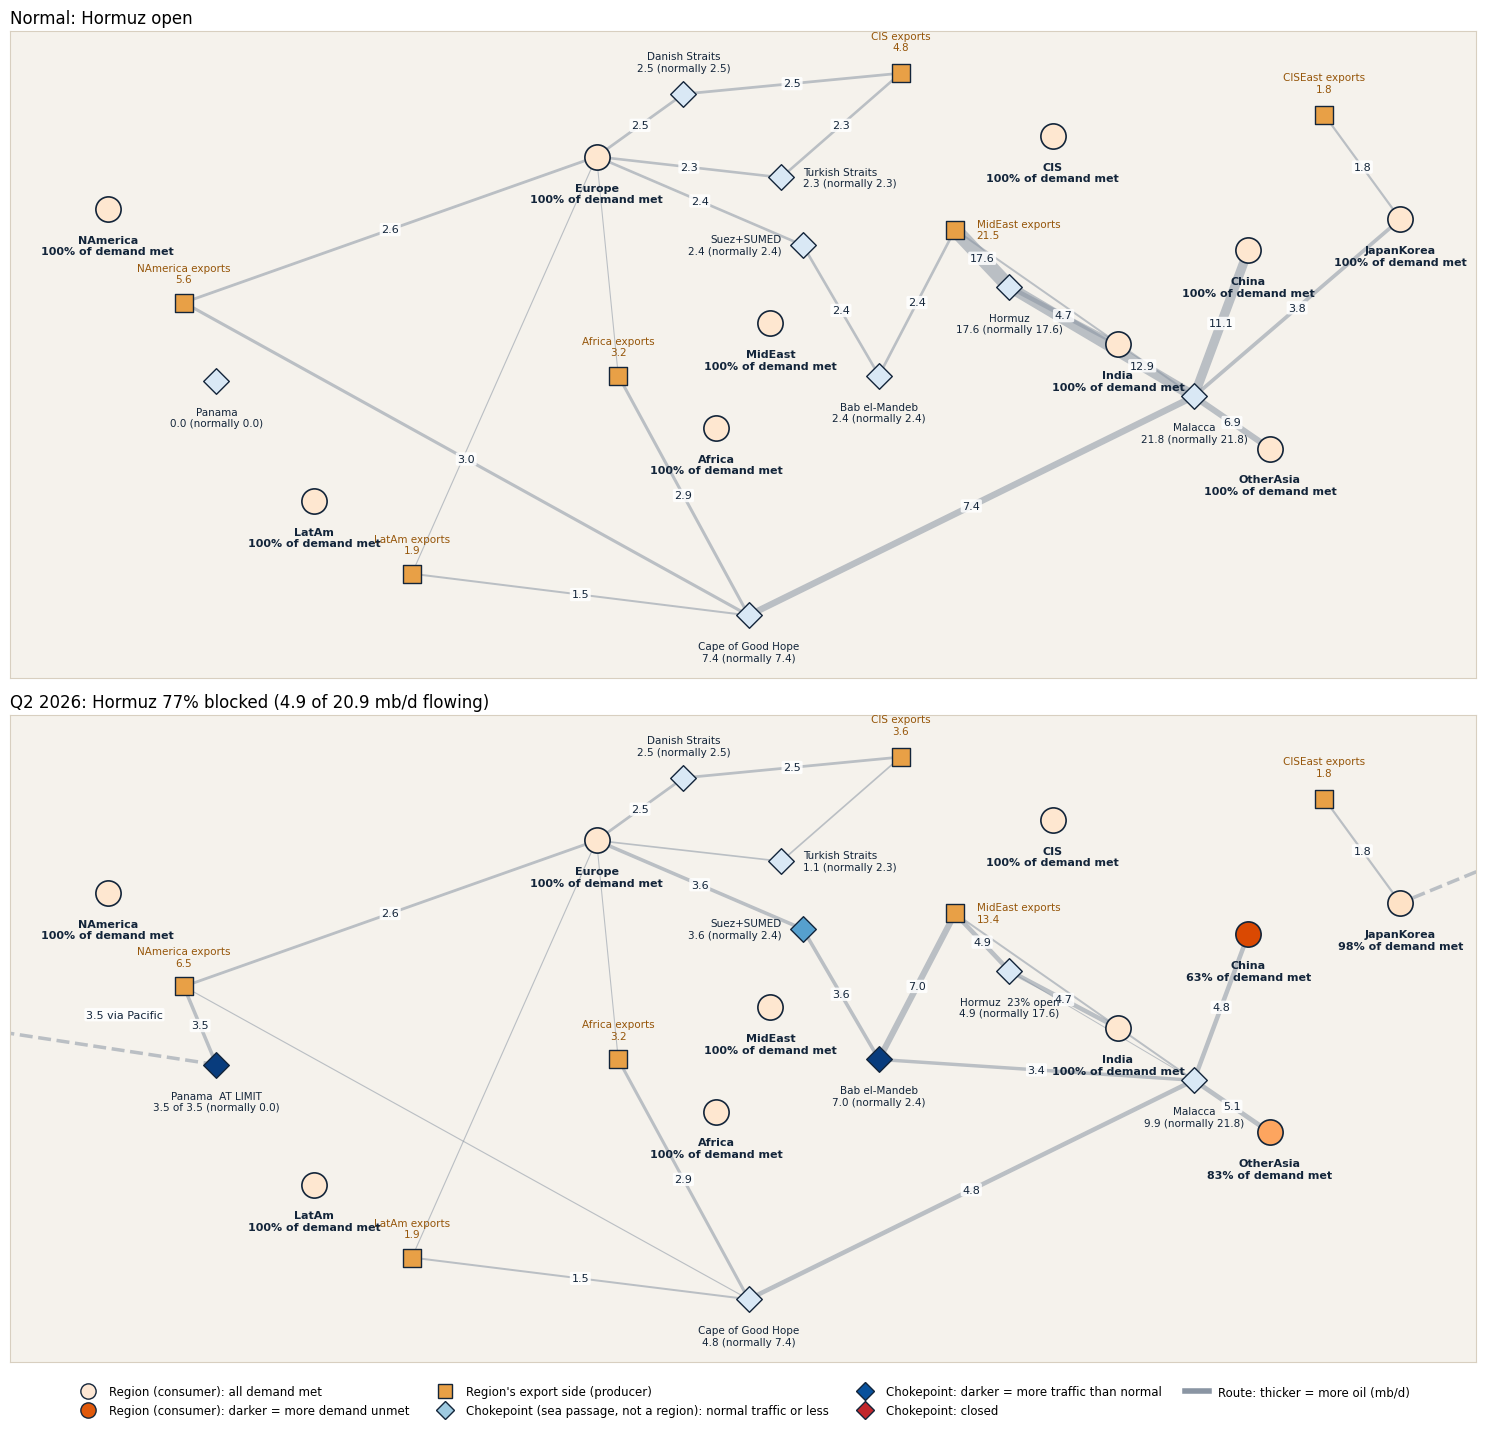

In [6]:
fig, path = draw([("Normal: Hormuz open", normal),                           # draw both scenarios as maps,
                   ("Q2 2026: Hormuz 77% blocked (4.9 of 20.9 mb/d flowing)", q2)],   # one panel each
                  out=FIG)                                                  # and save into figures/
plt.show()                                                                  # display it here

**What the tables show.**

- In normal conditions every region is fully supplied, and 38.8 mb/d moves between
  regions. The busiest corridor is Middle East → Hormuz → Malacca.
- Under the Q2 2026 closure, Hormuz fills to its reduced capacity (4.9 mb/d, exactly the observed flow), the Saudi
  pipeline carries 7.0 mb/d out through Bab el-Mandeb, and North America sends 3.5 mb/d
  across the Pacific through Panama.
- **Greedy routing is visible here.** Of the 4.9 mb/d still passing Hormuz, India takes
  4.7, because Gulf→India is the shortest voyage (6 days) and routes are filled
  fastest-first. India stays fully supplied while China falls to 63% of demand met. A market that
  allocated by need rather than distance would share the scarce Hormuz flow differently.

### The network as Hormuz closes step by step

The same map at 0%, 50%, 60%, 70% and 100% closure. Watch Hormuz darken, Panama fill
from 50% as North American oil starts crossing the Pacific to Japan/Korea, and China's
circle darken steadily. Other Asia holds at 89% up to 70% closure, then falls to 33% at
full closure, because its last Gulf oil still comes through Hormuz itself.

`snapshot` takes the **open** fraction, so 70% closed is `snapshot(hormuz_open=0.3)`.

Hormuz 0% closed     total short  0.00 mb/d   below 100%: none
Hormuz 50% closed    total short  1.21 mb/d   below 100%: {'China': '93%'}
Hormuz 60% closed    total short  4.46 mb/d   below 100%: {'China': '80%', 'OtherAsia': '89%'}
Hormuz 70% closed    total short  6.61 mb/d   below 100%: {'China': '66%', 'OtherAsia': '89%'}
Hormuz 100% closed   total short 12.77 mb/d   below 100%: {'China': '63%', 'JapanKorea': '98%', 'OtherAsia': '33%'}


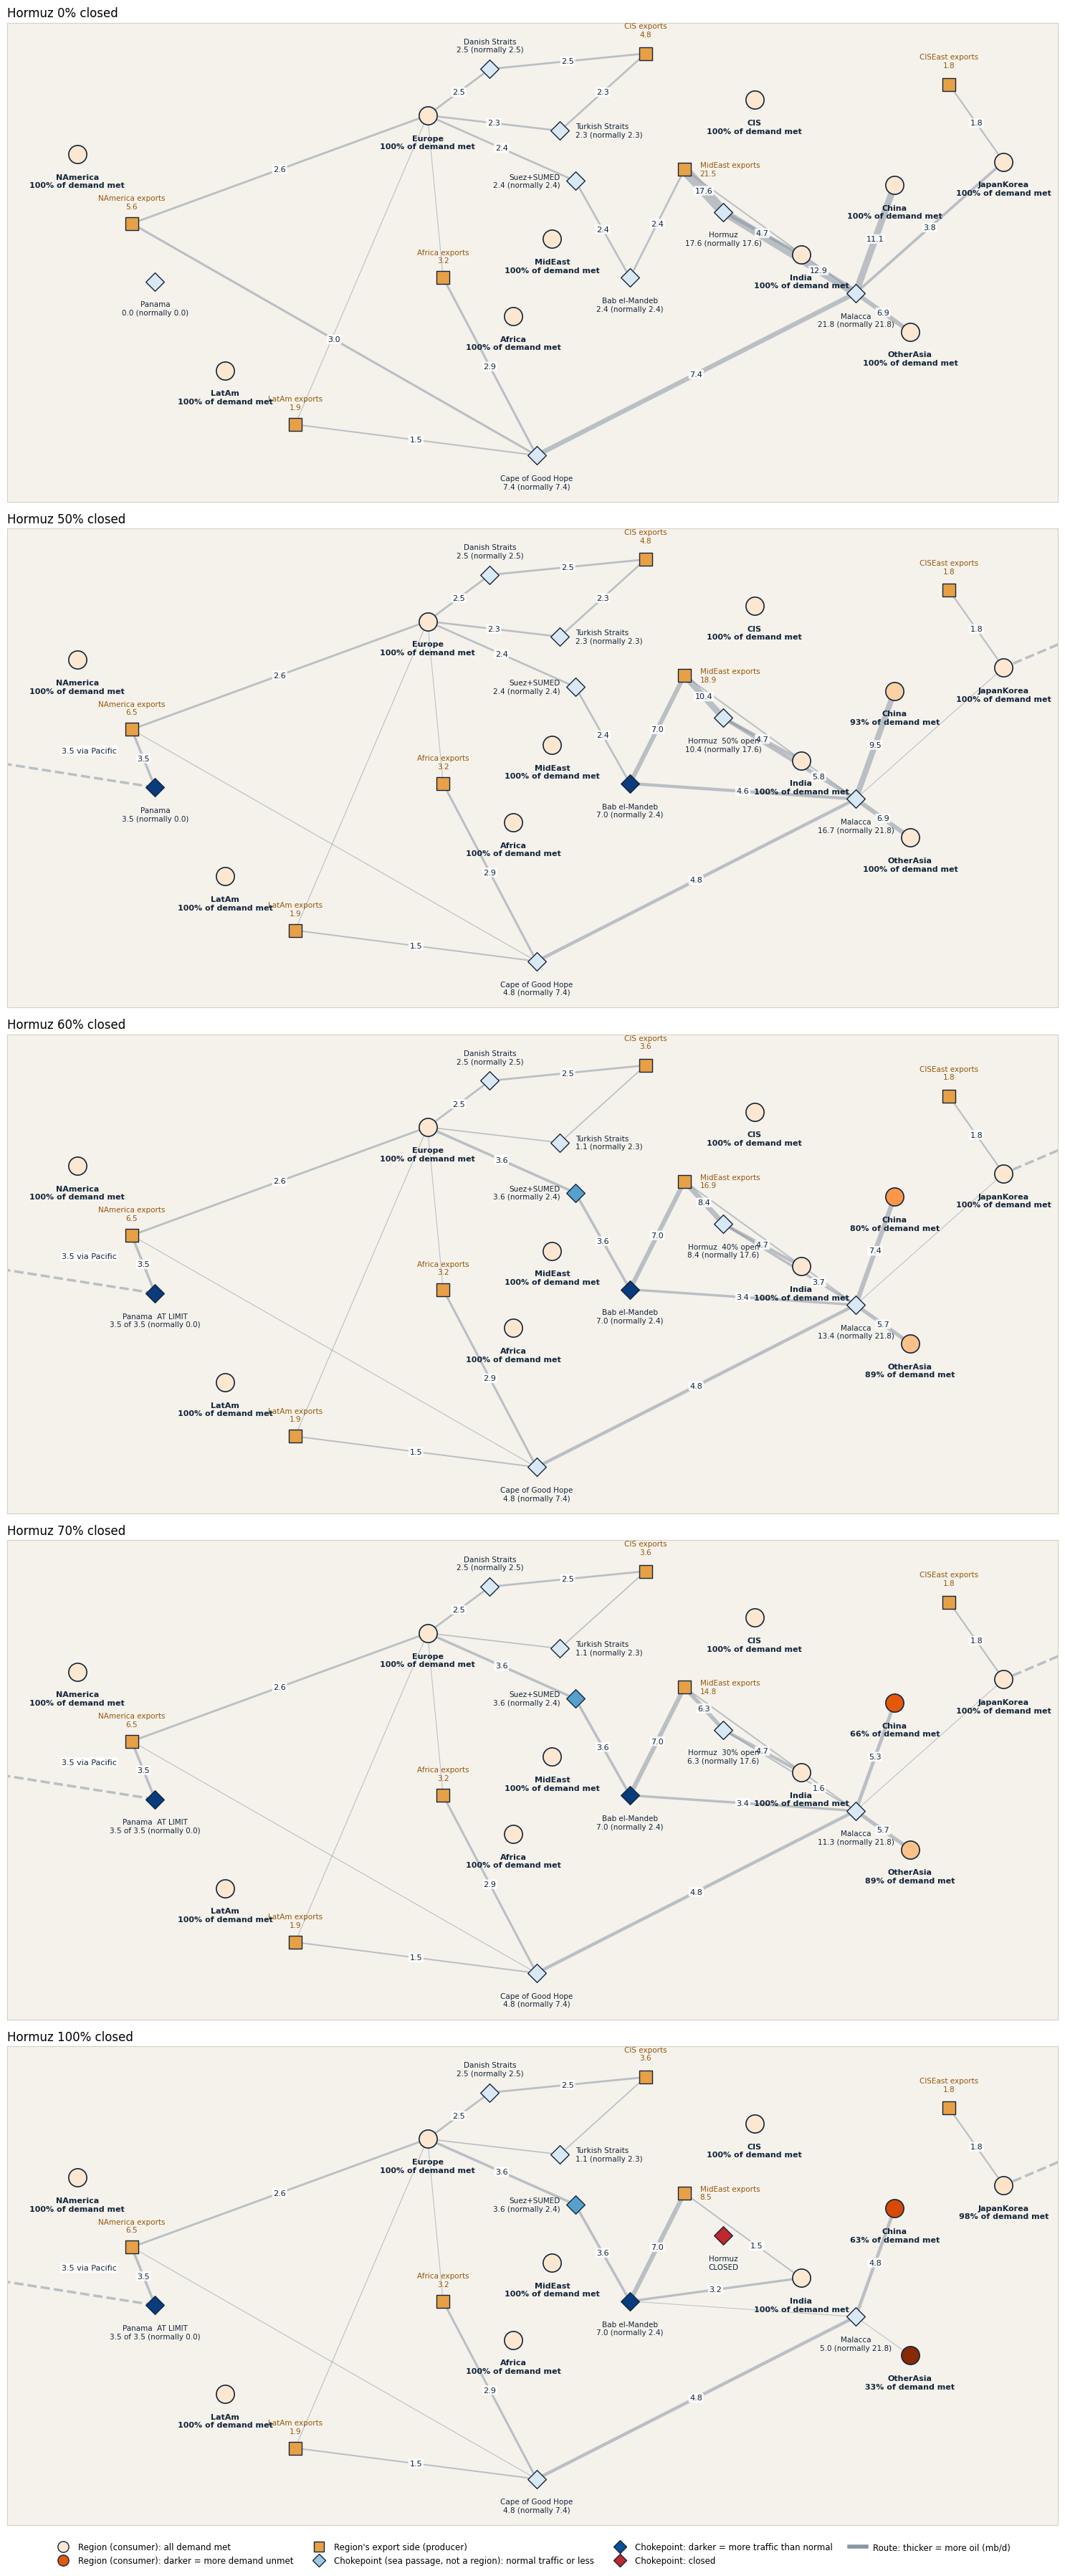

In [7]:
series = [(f"Hormuz {int(c*100)}% closed", snapshot(hormuz_open=1 - c))   # RUN the model once per closure level;
          for c in (0.0, 0.5, 0.6, 0.7, 1.0)]                             # snapshot takes the OPEN share, so 1 - closed
for title, s in series:
    hurt = {r: f"{d['supplied']:.0%}" for r, d in s["regions"].items() if d["supplied"] < 0.995}   # regions not fully met
    print(f"{title:<20} total short {sum(d['unserved'] for d in s['regions'].values()):5.2f} mb/d"
          f"   below 100%: {hurt or 'none'}")
fig, path = draw(series, fname="network_map_series.png", out=FIG)   # five stacked maps
plt.show()

## 2. Validation against observed data

Two checks, and it matters which is a genuine test.

**Baseline (undisrupted)** — nothing is set from observation, so every chokepoint
flow emerges from the routing rules and can be compared honestly with EIA 2023.

**Disruption** — we set Hormuz to the level observed in Q2 2026 (4.9 of 20.9 mb/d,
i.e. 23% open). Because Hormuz's flow is **set from observation**, its agreement is
*not* a test: it fills to the capacity we impose. The genuine test is the
**downstream corridors** — Malacca, Bab el-Mandeb, the Cape — whose flows are not
set but emerge from how the model reroutes oil.

In [8]:
m = OilNetworkModel()                    # build a fresh model (every region normal)
h = m.run(4.9/20.9, days=120)            # RUN it for 120 days with Hormuz 23% open (the Q2 2026 level)
pred = h['chokepoints'][-1]              # the flow through each passage on the last day
print(f"{'Chokepoint':<18}{'model':>8}{'observed':>10}{'2023 pre':>10}")
for cp in ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']:
    print(f"{cp:<18}{pred.get(cp,0):>8.1f}{OBSERVED_2026_Q2[cp]:>10.1f}{CHOKEPOINTS[cp][0]:>10.1f}")   # model vs EIA observed vs normal

Chokepoint           model  observed  2023 pre
Hormuz                 4.9       4.9      20.9
Malacca                9.9      16.6      23.7
Bab el-Mandeb          7.0       8.1       8.6
Suez+SUMED             3.6       5.8       8.8
Danish Straits         2.5       4.7       4.9


**Reading the result honestly.**

*Hormuz (5.0 vs 4.9) is not evidence.* We derived the closure level from the observed
4.9, so Hormuz simply fills to that ceiling. It only confirms the closure is applied.

*The genuine tests are quantities the model is not given.* Comparing crude with crude
(EIA: crude is ~73% of Hormuz flow, ~72% of Bab el-Mandeb, ~52% of Suez, ~5% of
Panama):

| Corridor | Model | Real crude | Verdict |
|---|---|---|---|
| Panama | 0.0 | ~0.1–0.2 | ✓ crude tankers cannot fit the canal |
| Suez | 2.4 | ~3.7 | under by about a third |
| Bab el-Mandeb | 2.4 | ~6.2 | under by more than half |

The remaining gaps are mostly refined products, which follow different trade routes
from crude and are not modelled, plus greedy routing concentrating flows.

*Price is the strongest validation*, because nothing about price is set from
observation. At the Q2 2026 operating point the model gives **$94 with full regional
reserves and $143 with none; observed Brent was ~$105** — inside the bracket, as
expected given the real IEA release (400 Mb) was a fraction of total regional stocks.

## 3. Congestion cascade and the closure response

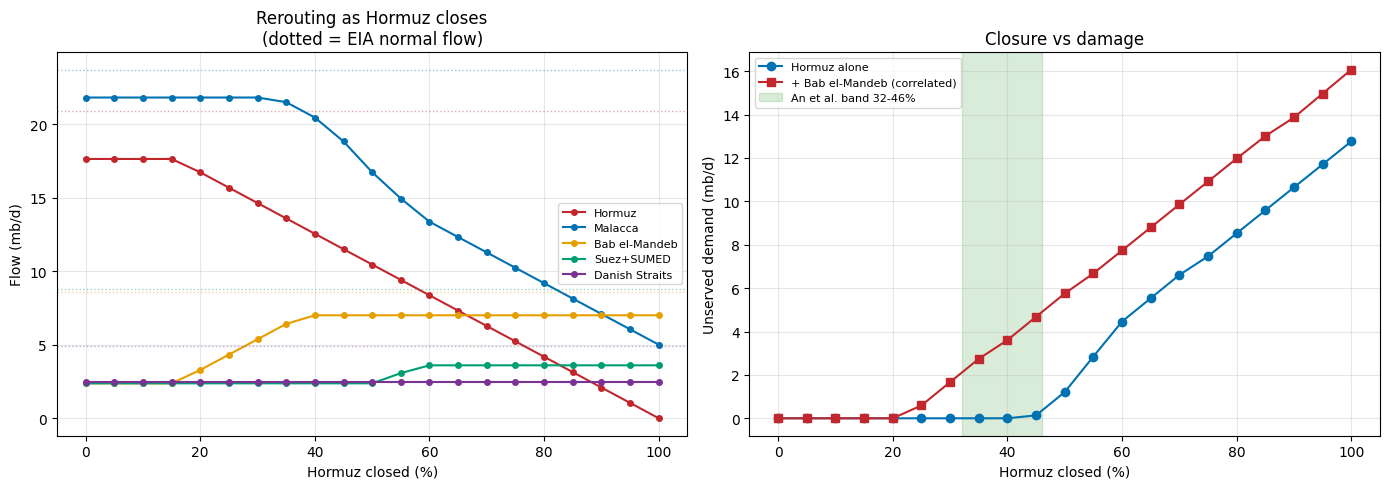

In [9]:
fr = np.linspace(0, 1, 21)                                  # closure levels 0%, 5%, ... 100%
cps = ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']   # passages to plot
flows = {c: [] for c in cps}; uns = []; uns_dual = []      # results: flow per passage, shortfall alone, shortfall + Bab
for f in fr:                                                # for each closure level...
    m = OilNetworkModel()                                   # ...a fresh model
    for _ in range(150): u, used, _ = m.step(1-f)           # 150 days with Hormuz f closed (step takes the OPEN share)
    for c in cps: flows[c].append(used.get(c, 0))           # record each passage's final flow
    uns.append(sum(u.values()))                             # and the world shortfall
    m2 = OilNetworkModel()                                  # a second model for the correlated case
    for _ in range(150): u2, _, _ = m2.step(1-f, extra_closed={'Bab el-Mandeb': 0.0})   # same, with Bab el-Mandeb shut too
    uns_dual.append(sum(u2.values()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))               # two charts side by side
cols = ['#c1272d','#0072b2','#e69f00','#009e73','#7b3294']  # one colour per passage
for c, col in zip(cps, cols):
    ax[0].plot(fr*100, flows[c], 'o-', label=c, color=col, ms=4)          # flow as Hormuz closes
    ax[0].axhline(CHOKEPOINTS[c][0], ls=':', color=col, alpha=.4, lw=1)   # dotted: EIA normal flow
ax[0].set_xlabel('Hormuz closed (%)'); ax[0].set_ylabel('Flow (mb/d)')
ax[0].set_title('Rerouting as Hormuz closes\n(dotted = EIA normal flow)'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(fr*100, uns, 'o-', label='Hormuz alone', color='#0072b2')                     # damage, Hormuz only
ax[1].plot(fr*100, uns_dual, 's-', label='+ Bab el-Mandeb (correlated)', color='#c1272d') # damage, both closed
ax[1].axvspan(32, 46, alpha=.15, color='green', label='An et al. band 32-46%')            # the published band
ax[1].set_xlabel('Hormuz closed (%)'); ax[1].set_ylabel('Unserved demand (mb/d)')
ax[1].set_title('Closure vs damage'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(f'{FIG}/1_chokepoint_response.png', dpi=130); plt.show()   # save and show

**Reading this:** as Hormuz closes, traffic pours into the Red Sea — Bab el-Mandeb
carries several times its normal flow. The bottleneck is not the strait, which is open
water, but the **Saudi East-West pipeline** that feeds it, which reaches its 7 mb/d limit.
Closing Bab el-Mandeb as well removes that escape route, and at 70% Hormuz closure raises
unserved demand by about half (6.6 → 9.9 mb/d).

## 4. Price dynamics and demand destruction

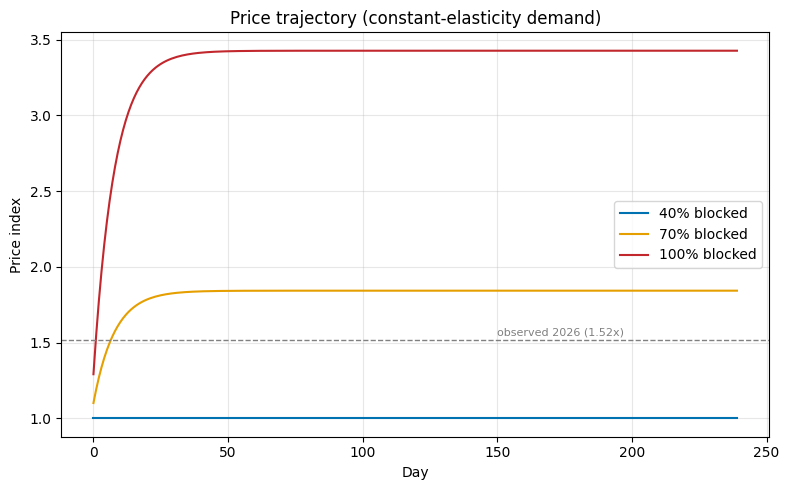

In [10]:
from price_dynamics import simulate_price                  # the day-by-day price simulation
fig, ax = plt.subplots(figsize=(8, 5))
for b, c in [(0.4,'#0072b2'), (0.7,'#e69f00'), (1.0,'#c1272d')]:   # three closure levels (share CLOSED)
    hh = simulate_price(b)                                  # RUN 240 days, no reserves
    ax.plot(hh['price'], color=c, label=f'{b:.0%} blocked') # price index over time (1.0 = $69)
ax.axhline(1.52, ls='--', c='grey', lw=1)                   # observed 2026: $105 / $69 = 1.52
ax.annotate('observed 2026 (1.52x)', xy=(150,1.55), fontsize=8, color='grey')
ax.set_xlabel('Day'); ax.set_ylabel('Price index'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Price trajectory (constant-elasticity demand)')
fig.tight_layout(); fig.savefig(f'{FIG}/2_price_dynamics.png', dpi=130); plt.show()

## 4b. Two views of the same shortage

The model measures a shortage twice. **Layer 1 (routing)** says which regions physically
cannot obtain oil. **Layer 2 (`clear_market`)** finds the price at which world demand falls
by exactly that amount, and says how much each region would cut at that price. The totals
are equal by construction. The split between regions is not — because the cuts are
**never fed back into the routing**.

In [11]:
from price_dynamics import shortage_two_views    # physical shortfall vs price-driven cuts
p, views = shortage_two_views(1.0)                 # RUN at full closure (share CLOSED)
print(f"Full closure: clearing price {p:.2f}x (Brent ${69*p:.0f})\n")
print(f"{'region':<12}{'demand':>8}{'physical short':>16}{'cut at that price':>19}{'cut %':>8}")
for r, (d, phys, cut) in sorted(views.items(), key=lambda x: -x[1][2]):    # biggest price cut first
    print(f"{r:<12}{d:8.1f}{phys:16.2f}{cut:19.2f}{cut/d:8.1%}")
print(f"{'TOTAL':<12}{sum(v[0] for v in views.values()):8.1f}"
      f"{sum(v[1] for v in views.values()):16.2f}{sum(v[2] for v in views.values()):19.2f}")

Full closure: clearing price 3.43x (Brent $236)

region        demand  physical short  cut at that price   cut %
China           16.4            6.02               2.25   13.7%
OtherAsia       10.0            6.65               2.18   21.8%
Europe          14.5            0.00               1.52   10.5%
NAmerica        24.6            0.00               1.47    6.0%
India            5.6            0.00               1.22   21.8%
Africa           4.4            0.00               1.17   26.5%
LatAm            6.5            0.00               1.10   16.9%
MidEast          9.5            0.00               0.89    9.4%
CIS              4.8            0.00               0.56   11.6%
JapanKorea       5.7            0.10               0.41    7.1%
TOTAL          102.0           12.77              12.77


**Reading the table.** The routing puts the whole shortage in Asia (China, Other Asia,
Japan/Korea); Europe, North America and Africa receive every barrel they want. The market
says that at ~$236 *everyone* cuts back — Africa by about a quarter, India and Other Asia
by a fifth, Europe by a tenth.

In reality the outcome lies between the two: high prices would make Europe and North
America use less, and the oil they stopped buying would be sold to Asia. The model never
lets that freed oil move, so **the concentration of damage in Asia is probably overstated**.
The price view also shows who bears price rationing: the most price-sensitive, and
typically poorest, regions — not necessarily those whose supply was cut.

## 5. Strategic reserves: how long do they last?

In [12]:
from spr_depletion import simulate_with_reserve, runway_days   # reserve simulation; volume / rate helper

print("Each region's reserve, if drawn flat out (volume / max draw rate):")
for r, mb in sorted(REGIONAL_RESERVES.items(), key=lambda x: -x[1]):   # largest first
    if mb > 0:
        print(f"  {r:<11}{mb:6.0f} Mb at {REGIONAL_DRAW_RATE[r]:.1f} mb/d -> "
              f"{runway_days(mb, REGIONAL_DRAW_RATE[r]):4.0f} days")      # e.g. China 1,400 / 4.0 = 350 days

print(f"\n{'closure':>9}{'all reserves empty':>20}{'peak Brent':>13}")
for b in [0.3, 0.5, 0.7, 0.85, 1.0]:                        # closure levels (share CLOSED)
    hh = simulate_with_reserve(b)                           # RUN 400 days with realistic regional reserves
    e = next((d for d,r in enumerate(hh['reserve']) if r<=0), None)   # first day ALL reserves are gone (if ever)
    print(f"{b:>8.0%}{('day '+str(e)) if e else 'never':>20}{max(hh['brent']):>12.0f}")

Each region's reserve, if drawn flat out (volume / max draw rate):
  China        1400 Mb at 4.0 mb/d ->  350 days
  JapanKorea    449 Mb at 2.0 mb/d ->  224 days
  NAmerica      285 Mb at 2.7 mb/d ->  106 days
  Europe        179 Mb at 1.5 mb/d ->  119 days
  OtherAsia      50 Mb at 0.3 mb/d ->  167 days
  India          39 Mb at 0.5 mb/d ->   78 days

  closure  all reserves empty   peak Brent
     30%               never          69
     50%               never          69


     70%               never         127
     85%               never         169


    100%               never         234


**Key result:** reserves cushion rather than prevent. Each region draws only on its
own stocks (China ~1,400 Mb, Japan/Korea 449, US 285, Europe 179). At full closure,
day 100, Brent is ~$151 with reserves against ~$236 without. The US SPR cannot relieve
an Asian shortage.

## 6. Downstream production cascade

In [13]:
from production_cascade import regional_cascade, critical_blockade_intensity   # Layer 3 and the threshold
for b in [0.4, 0.6, 0.8, 1.0]:                              # closure levels (share CLOSED)
    res = regional_cascade(b)                               # RUN the network, then each region's sector cascade
    line = "  ".join(f"{r}: {v['systemic_loss']:.0%}" for r,v in res.items())   # each region's systemic loss
    print(f"  blockade {b:>4.0%} | {line}")
crit = critical_blockade_intensity()                        # bisection: where the worst region first passes 10%
print(f"\nCRITICAL BLOCKADE INTENSITY: {crit:.0%}   (An et al. 2026: 32-46%)")

  blockade  40% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 0%  India: 0%  JapanKorea: 0%  OtherAsia: 0%
  blockade  60% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 18%  India: 0%  JapanKorea: 0%  OtherAsia: 10%
  blockade  80% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 34%  India: 0%  JapanKorea: 2%  OtherAsia: 21%
  blockade 100% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 34%  India: 0%  JapanKorea: 2%  OtherAsia: 89%



CRITICAL BLOCKADE INTENSITY: 53%   (An et al. 2026: 32-46%)


## 6b. Inside the production cascade

For each sector, four numbers decide its output:

- **direct** — what is left of its inputs after its **own** oil shortage:
  `1 − oil_dependence × (1 − oil_available)`
- **upstream** — what is left after its **supplier sectors** fail (in the same region):
  `1 − Σ need × (1 − supplier's output)`. Industry needs Transport 0.45, Petrochemicals
  0.35, Power 0.30.
- **effective** — the worse of the two: `min(direct, upstream)`
- **output** — `effective × gate(effective)`, where the **gate** is an S-shaped switch
  that is ~1 above 60% of inputs, 0.5 at 45%, and ~0 below 30%: below a minimum, a sector
  cannot operate at all.

Each sector's output feeds the others' *upstream*, so the calculation repeats until
nothing changes. **Systemic loss** = Σ weight × (1 − output), the weight being the
sector's share of oil use.

In [14]:
from production_cascade import explain_cascade        # every intermediate step, for one region

def show(oil_available, title):
    rows, sysl = explain_cascade(oil_available)     # RUN the cascade at this oil supply
    print(f"{title}: oil available {oil_available:.1%}")
    print(f"  {'sector':<17}{'direct':>8}{'upstream':>10}{'effective':>11}{'gate':>7}{'output':>8}{'weight':>8}{'loss':>7}")
    for s, d in rows.items():
        print(f"  {s:<17}{d['direct']:8.3f}{d['upstream']:10.3f}{d['effective']:11.3f}"
              f"{d['gate']:7.3f}{d['output']:8.3f}{d['weight']:8.2f}{d['loss']:7.3f}")
    print(f"  {'systemic loss':<17}{'':51}{sysl:7.3f}\n")

china = regional_cascade(crit)['China']['oil_available']   # China's oil supply AT the threshold
show(china, "China at the threshold")
show(0.50, "A severe case")

China at the threshold: oil available 88.6%
  sector             direct  upstream  effective   gate  output  weight   loss
  Transport           0.895     1.000      0.895  0.999   0.894    0.57  0.060
  Petrochemicals      0.891     0.963      0.891  0.999   0.891    0.21  0.023
  Industry            0.949     0.908      0.908  1.000   0.907    0.07  0.006
  Agri/Residential    0.954     0.914      0.914  1.000   0.914    0.11  0.009
  Power               0.989     0.979      0.979  1.000   0.979    0.04  0.001
  systemic loss                                                         0.100

A severe case: oil available 50.0%
  sector             direct  upstream  effective   gate  output  weight   loss
  Transport           0.540     1.000      0.540  0.818   0.441    0.57  0.318
  Petrochemicals      0.525     0.804      0.525  0.777   0.408    0.21  0.124
  Industry            0.775     0.508      0.508  0.724   0.368    0.07  0.044
  Agri/Residential    0.800     0.543      0.543  0.

**Reading the tables.**

*At the threshold* China gets ~89% of its oil. Industry's **own** oil shortage would leave
it at 94.9% (direct), but its suppliers — trucks and chemicals — are down, so it can only
run at 90.8% (upstream). It is limited by its suppliers, not its own oil: that is the
cascade, and it is what makes the damage *systemic*. The gate is ~1 because every sector
is far above the 45% line, so output ≈ effective.

*In the severe case* (50% of oil) the gate bites. Transport's inputs fall to 54%, the gate
gives 0.82, so output is 0.54 × 0.82 = 44%. Industry is barely oil-dependent (direct 77.5%)
but its suppliers have collapsed (upstream 50.8%), and it ends at 37%. **Systemic loss is
55% — more than the 50% oil shortfall**: the cascade amplifies the shock.

This is also why the threshold barely moves when the 45% shutdown line is changed (52.6–
53.1% across 30–60%): at the threshold every sector is near 90% of its inputs, where the
gate is ~1 whichever line is used.

## 7. Strategic reserves — does location matter?

Reserves are held nationally: the US SPR cannot be shipped to China. We compare three
cases at full closure — no reserves, realistic regional reserves (each region draws
only on its own stocks), and a hypothetical world where all ~2,400 Mb could be pooled
and sent wherever the shortage is.

The gap between the regional and pooled curves measures the cost of reserves being in
the wrong place relative to where the shortage falls.

No reserves                  Brent day 100: $  236   peak $  236


Regional (realistic)         Brent day 100: $  151   peak $  234


Hypothetical global pool     Brent day 100: $   81   peak $  236


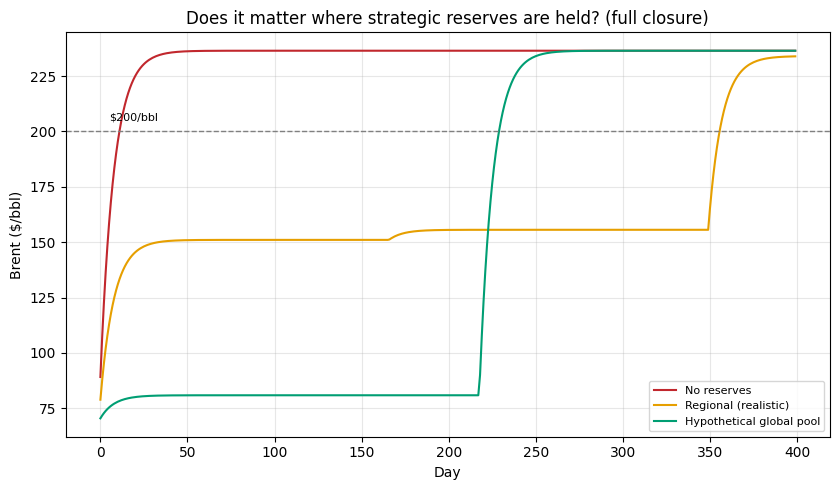

In [15]:
from oil_model_data import REGIONAL_RESERVES, REGIONAL_DRAW_RATE
total_reserves = sum(REGIONAL_RESERVES.values())    # ~2,400 Mb across six regions
total_rate     = sum(REGIONAL_DRAW_RATE.values())   # ~11 mb/d - the pool gets the SAME total draw speed,
                                                     # so the comparison isolates LOCATION only

scenarios = {                                        # three cases that genuinely differ
    'No reserves':                 dict(scale=0.0),                  # scale 0 switches every reserve off
    'Regional (realistic)':        dict(regional=True),              # each region uses only its own
    'Hypothetical global pool':    dict(regional=False, reserve_mb=total_reserves,
                                        draw_rate=total_rate),       # one pool, drawn wherever needed
}
fig, ax = plt.subplots(figsize=(8.5, 5))
for (lab, kw), c in zip(scenarios.items(), ['#c1272d', '#e69f00', '#009e73']):
    hh = simulate_with_reserve(1.0, days=400, **kw)  # RUN 400 days at FULL closure
    ax.plot(hh['brent'], color=c, label=lab)         # Brent price over time
    print(f"{lab:<28} Brent day 100: ${hh['brent'][100]:5.0f}   peak ${max(hh['brent']):5.0f}")
ax.axhline(200, ls='--', c='grey', lw=1); ax.annotate('$200/bbl', xy=(5, 205), fontsize=8)
ax.set_xlabel('Day'); ax.set_ylabel('Brent ($/bbl)'); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title('Does it matter where strategic reserves are held? (full closure)')
fig.tight_layout(); fig.savefig(f'{FIG}/3_interventions.png', dpi=130); plt.show()

**Result — reserves are in the wrong place.** With both cases drawing at the same total
rate (11 mb/d), pooled reserves hold Brent near **$81** at day 100 against **$151** for
realistic regional reserves.

The regional reserves are *never exhausted*: the US (285 Mb), Europe (179 Mb) and India
(39 Mb) are not short, so ~500 Mb is never drawn, and Japan/Korea uses only 39 of its
449 Mb — while China exhausts all 1,400 Mb. The constraint on
strategic reserves in a Hormuz closure is not how much oil exists, but whether it sits
where the shortage falls.

## 7b. Which intervention raises the threshold most?

This answers the second half of the research question. Each intervention works through
its real channel:

- **Bypass** adds Saudi East-West pipeline capacity *inside the network*, so the extra oil
  must still find a route.
- **Demand restraint** cuts consumption in every region *inside the network*, so oil freed
  in one region can be bought by another.
- **Strategic reserves** are national: relief stays in the region that holds them.

Two comparisons answer two questions: at **equal size** (~3 mb/d each), which is most
effective *per barrel*? At **realistic size**, which helps most *in practice*?
*(This cell takes a few minutes.)*

Intervention                    Size        Threshold     Shift
Baseline                        -              53.1%     +0.0 pts
Bypass +3 mb/d                  equal          67.5%    +14.4 pts
Demand restraint 2.9%           equal          59.6%     +6.5 pts
Reserves at 3 mb/d total        equal          58.2%     +5.1 pts
Bypass +2 mb/d                  realistic      62.7%     +9.6 pts
Demand restraint 3%             realistic      59.9%     +6.8 pts
Reserves, realistic ~11 mb/d    realistic      71.7%    +18.6 pts
All three combined              realistic      91.1%    +38.0 pts


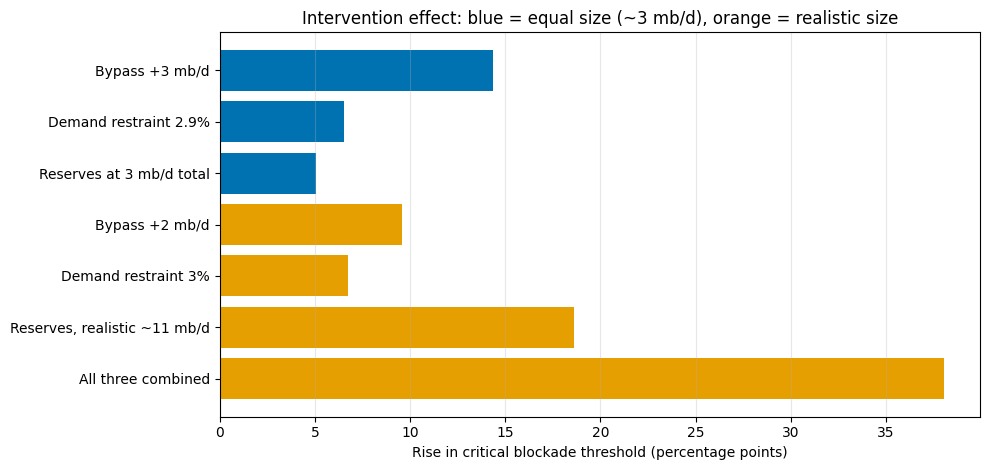


At 71% closure with realistic regional reserves:
  OtherAsia reserve exhausted on day 167
  China reserve exhausted on day 350
  day 150: worst-region systemic loss 9.2%
  day 200: worst-region systemic loss 9.6%
  day 400: worst-region systemic loss 31.9%


In [16]:
from production_cascade import compare_interventions, reserve_hold_time

rows = compare_interventions()                       # RUN the threshold search for all 8 cases (slow)
print(f"{'Intervention':<32}{'Size':<11}{'Threshold':>10}{'Shift':>10}")
for r in rows:
    print(f"{r['name']:<32}{r['size']:<11}{r['threshold']:>9.1%}{100*r['shift']:>+9.1f} pts")   # how far each moves it

fig, ax = plt.subplots(figsize=(10, 4.8))
shown = [r for r in rows if r['name'] != 'Baseline'] # every case except the baseline
cols = {'equal': '#0072b2', 'realistic': '#e69f00'}  # blue = equal size, orange = realistic size
ax.barh([r['name'] for r in shown], [100*r['shift'] for r in shown],
        color=[cols[r['size']] for r in shown])      # one bar per intervention
ax.set_xlabel('Rise in critical blockade threshold (percentage points)')
ax.set_title('Intervention effect: blue = equal size (~3 mb/d), orange = realistic size')
ax.invert_yaxis(); ax.grid(alpha=.3, axis='x')
fig.tight_layout(); fig.savefig(f'{FIG}/5_interventions_threshold.png', dpi=130); plt.show()

# Reserves only help while they last. Test just below the threshold they appear to give (71.7%).
worst, exhausted = reserve_hold_time(0.71)            # RUN 400 days at 71% closure with reserves drawn
print("\nAt 71% closure with realistic regional reserves:")
for r, d in sorted(exhausted.items(), key=lambda x: x[1]):
    print(f"  {r} reserve exhausted on day {d}")      # when each reserve ran dry
for d in (150, 200, 400):
    print(f"  day {d}: worst-region systemic loss {worst[d-1]:.1%}")   # above 10% = systemic

**Answer.**

*Per barrel, bypass capacity is the most effective intervention* — at ~3 mb/d each, extra
pipeline capacity raises the threshold by about 14 points, demand restraint by about 7,
and reserves by about 5. Bypass oil is real Gulf supply that would otherwise be stranded,
and it travels through the network to wherever the shortage is; reserves are national,
so much of their relief lands in regions that are not short.

*In practice, reserves raise the threshold most* — about 19 points — but only because the
realistic volume (~11 mb/d of drawdown) dwarfs a 2 mb/d pipeline expansion, and **only
temporarily**. At 71% closure, just below the reserves-raised threshold, reserves hold the worst region (China) below systemic loss (9.2% on day 150) until China's 1,400 Mb runs out on day 350; the system turns systemic the next day. Other Asia's small stock runs out on day 167 without tipping it at this closure. Bypass and
demand restraint do not expire.

Combined, the three realistic interventions raise the threshold by about 38 points.

*Caveat:* demand restraint is treated as costless supply relief, as the IEA counts it; in
reality cutting consumption has an economic cost the model does not charge.

## 8. Network topology analysis (Lectures 2–3 tools)

We apply the unit's network-science tools — betweenness centrality, and
comparison against Erdős–Rényi, Watts–Strogatz, Barabási–Albert and a
degree-preserving null model — to the real route network.

In [17]:
from topology_comparison import (build_real_graph, chokepoint_betweenness,
                                  vulnerability, capacity_vulnerability,
                                  comparison_networks)        # lecture network tools
G = build_real_graph()                                         # the routes as a graph: producers, chokepoints, consumers
print(f"Real network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")
for cp, v in sorted(chokepoint_betweenness(G).items(), key=lambda x:-x[1]):   # most central chokepoint first
    print(f"  {cp:<20}{v:6.3f}")                               # betweenness: share of shortest paths through it
print(f"\nTargeted removal of most-central node:")
print(f"  connectivity lost: {vulnerability(G):.1%}  (paths still exist)")      # can everyone still reach a producer?
print(f"  CAPACITY lost:     {capacity_vulnerability(G):.1%}  <- what matters") # how much carrying capacity is lost?

Real network: 22 nodes, 39 edges

  Malacca              0.310
  Cape of Good Hope    0.300
  Bab el-Mandeb        0.191
  Suez+SUMED           0.127
  Turkish Straits      0.062
  Panama               0.054
  Danish Straits       0.029
  Hormuz               0.028

Targeted removal of most-central node:
  connectivity lost: 0.0%  (paths still exist)
  CAPACITY lost:     5.6%  <- what matters


**Hormuz ranks almost last on betweenness (0.03), while Malacca (0.31) and the Cape (0.30)
rank highest.** Betweenness counts *paths*, not barrels: on the map, Hormuz serves only one
origin, and that origin has other exits (the Saudi and UAE pipelines), so few shortest paths
depend on it. Its real importance is the *volume* it carries — 20.9 mb/d — which pure
topology cannot see. This is the clearest argument for a capacitated flow model rather than
topology alone. (The capacity measure below gives every route a capacity of 1, so it counts
separate paths: 18 before Malacca is removed, 17 after, a 5.6% loss.)

### Comparison against the taught network generators

Is the real oil network unusually vulnerable *for its size and density*? We
compare it against networks from Lectures 2–3 — Erdős–Rényi, Watts–Strogatz,
Barabási–Albert — all matched on node and edge count, plus a **degree-preserving
rewiring** of the real network (the standard null model in network science:
keep every node's number of connections, shuffle which connections they are).

If the real network were *more* vulnerable than its randomised counterparts,
that would mean its specific arrangement is the problem. If comparable, the
vulnerability lies elsewhere — in capacity, not topology.

Real network capacity vulnerability: 5.6%

network                         mean     std   verdict
  Erdos-Renyi                  11.5%    5.3%   real LESS vulnerable
  Watts-Strogatz               24.9%    9.5%   real LESS vulnerable
  Barabasi-Albert              14.4%    6.5%   real LESS vulnerable
  Degree-preserving rewire     15.1%    5.4%   real LESS vulnerable


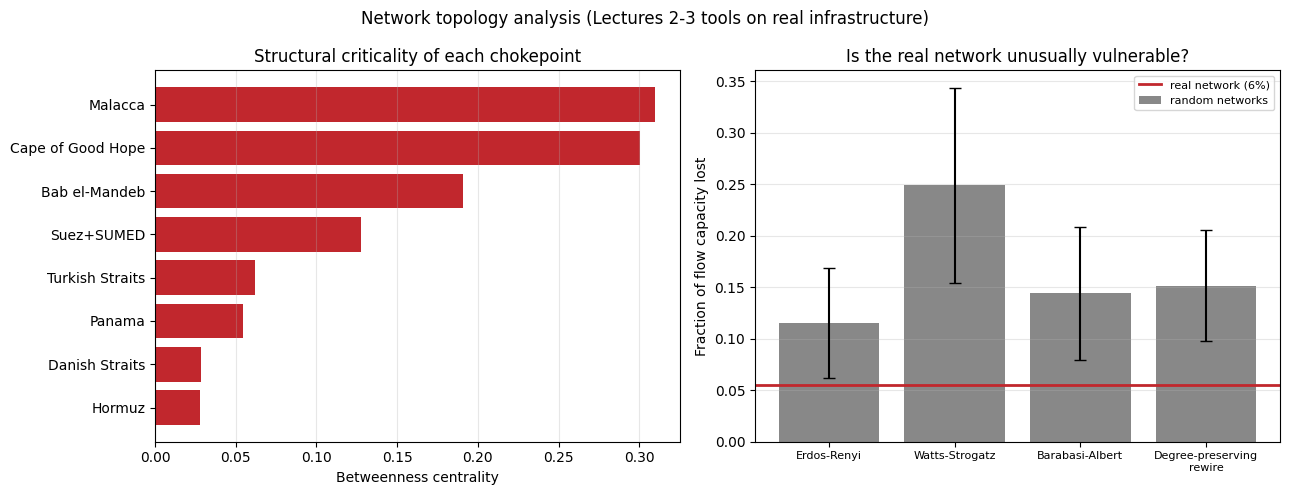

In [18]:
v_real = capacity_vulnerability(G)                  # the real network's capacity loss
comps = comparison_networks(G, n_samples=100)       # 100 random graphs each: ER, WS, BA, rewired

print(f"Real network capacity vulnerability: {v_real:.1%}\n")
print(f"{'network':<28}{'mean':>8}{'std':>8}   verdict")
labels, means, stds = [], [], []
for name, vals in comps.items():                    # for each kind of random network...
    vals = [x for x in vals if not np.isnan(x)]     # drop failed samples
    if not vals: continue
    mu, sd = np.mean(vals), np.std(vals)            # average loss and its spread
    verdict = ("real MORE vulnerable" if v_real > mu + sd else       # more than one spread away = a real difference
               "real LESS vulnerable" if v_real < mu - sd else "comparable")
    print(f"  {name:<26}{mu:>8.1%}{sd:>8.1%}   {verdict}")
    labels.append(name.replace(' ', '\n')); means.append(mu); stds.append(sd)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
bc = chokepoint_betweenness(G)                      # betweenness of each chokepoint
names = sorted(bc, key=bc.get)
ax[0].barh(names, [bc[n] for n in names], color='#c1272d')
ax[0].set_xlabel('Betweenness centrality')
ax[0].set_title('Structural criticality of each chokepoint')
ax[0].grid(alpha=.3, axis='x')

x = np.arange(len(labels))
ax[1].bar(x, means, yerr=stds, capsize=4, color='#888', label='random networks')        # random graphs, with spread
ax[1].axhline(v_real, color='#c1272d', lw=2, label=f'real network ({v_real:.0%})')      # the real network
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8)
ax[1].set_ylabel('Fraction of flow capacity lost')
ax[1].set_title('Is the real network unusually vulnerable?')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, axis='y')
fig.suptitle('Network topology analysis (Lectures 2-3 tools on real infrastructure)')
fig.tight_layout(); fig.savefig(f'{FIG}/4_topology_comparison.png', dpi=130); plt.show()

**Result:** the real network is **more robust than every comparison network**.
Removing its most central chokepoint costs 5.6% of flow capacity, against 12–27%
for Erdős–Rényi, Watts–Strogatz, Barabási–Albert and degree-preserving rewires of
the same size.

The reason is redundancy: real oil trade has several parallel routes between the
same pair of regions — Middle East to Europe via Suez, via the Cape, and via the
Saudi pipeline — which random graphs of equal size rarely produce. Vulnerability
in this system comes from **capacity concentration** on a few high-volume routes,
not from fragile topology. That is why capacity and threshold dynamics were
needed rather than topology alone.

**Key insight:** removing the most critical chokepoint disconnects **nothing** —
a path always exists — yet flow *capacity* is still lost. Pure graph theory calls
this network robust because every node stays connected; it cannot say how much oil
those surviving paths can carry. Connectivity and capacity are different
questions, and only the second determines whether a region gets its oil.

## 9. Sensitivity analysis

Several parameters are our own calibration choices rather than published
values. We sweep each to see how far the headline results move.

In [19]:
import sensitivity as S                              # parameter sweeps
v, o = S.sweep_operability_min()                     # RUN the threshold search for several operability floors
print("Operability floor -> critical blockade")
for a, b in zip(v, o):
    print(f"  floor {a:.2f} -> {b if b is None else f'{b:.0%}'}")   # does the 45% assumption move the threshold?
print("\nPath dependence (matched total blockade-days):")
for lab, (bd, val) in S.path_dependence_test().items():           # same total disruption, different shapes over time
    print(f"  {lab:<18} blockade-days {bd:6.1f} -> unserved {val:5.2f}")

Operability floor -> critical blockade
  floor 0.30 -> 53%
  floor 0.35 -> 53%
  floor 0.40 -> 53%
  floor 0.45 -> 53%
  floor 0.50 -> 53%
  floor 0.55 -> 53%
  floor 0.60 -> 53%

Path dependence (matched total blockade-days):
  sudden then ease   blockade-days   75.0 -> unserved  3.41
  ease then sudden   blockade-days   75.0 -> unserved  3.41
  gradual ramp       blockade-days   82.5 -> unserved  3.26
  oscillating        blockade-days   82.5 -> unserved  4.26


## 9b. Closure sensitivity — Hormuz, Bab el-Mandeb, and both

We sweep the closure of each chokepoint from 0 to 100%, alone and in combination, and
record unserved demand and the equilibrium Brent price. The two real 2026 operating
points are marked with stars:

- **Q2 2026 (EIA):** Hormuz 77% blocked (4.9 of 20.9 mb/d flowing), Bab el-Mandeb
  effectively open. Observed Brent ~$105.
- **Sep 2026 (approximate):** convoys and pipelines had narrowed crude losses to about
  45% of pre-war levels, while Yanbu loadings on the Red Sea were halted. Recorded as
  Hormuz ~45% blocked with the Red Sea route heavily impaired.

Prices here are equilibrium prices **without** strategic reserves, so they show the
structural pressure on the market. *(This cell takes a few minutes.)*

Q2 2026 (EIA)        Hormuz 77%  Bab 6%  ->  unserved  7.80 mb/d   Brent $ 143  (observed $105)
Sep 2026 (approx)    Hormuz 45%  Bab 60%  ->  unserved  3.80 mb/d   Brent $  97


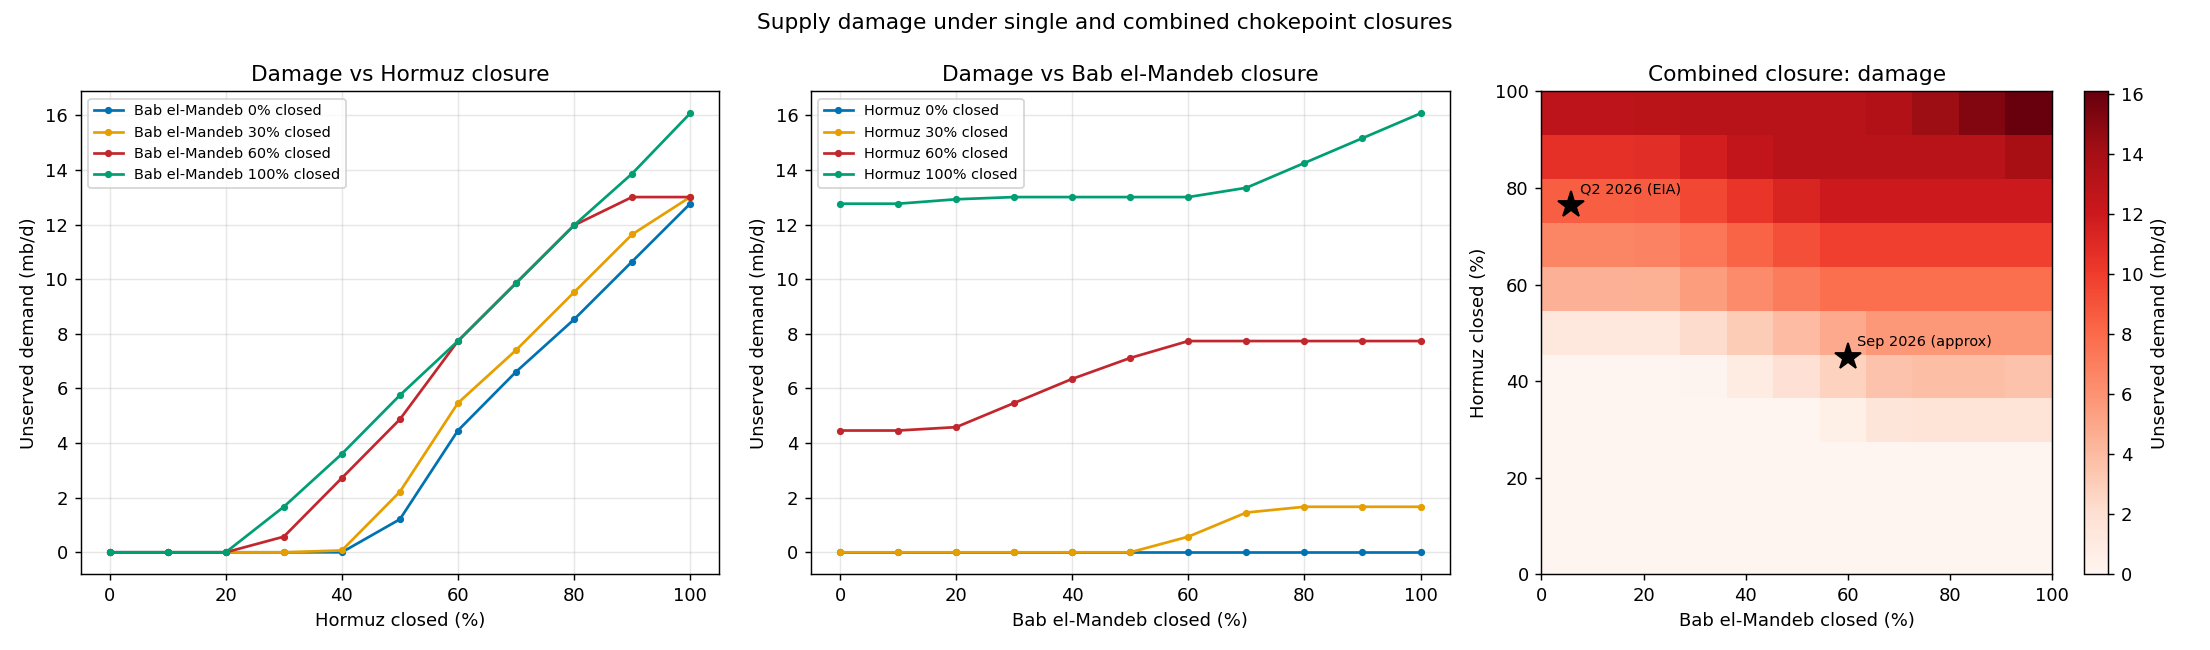

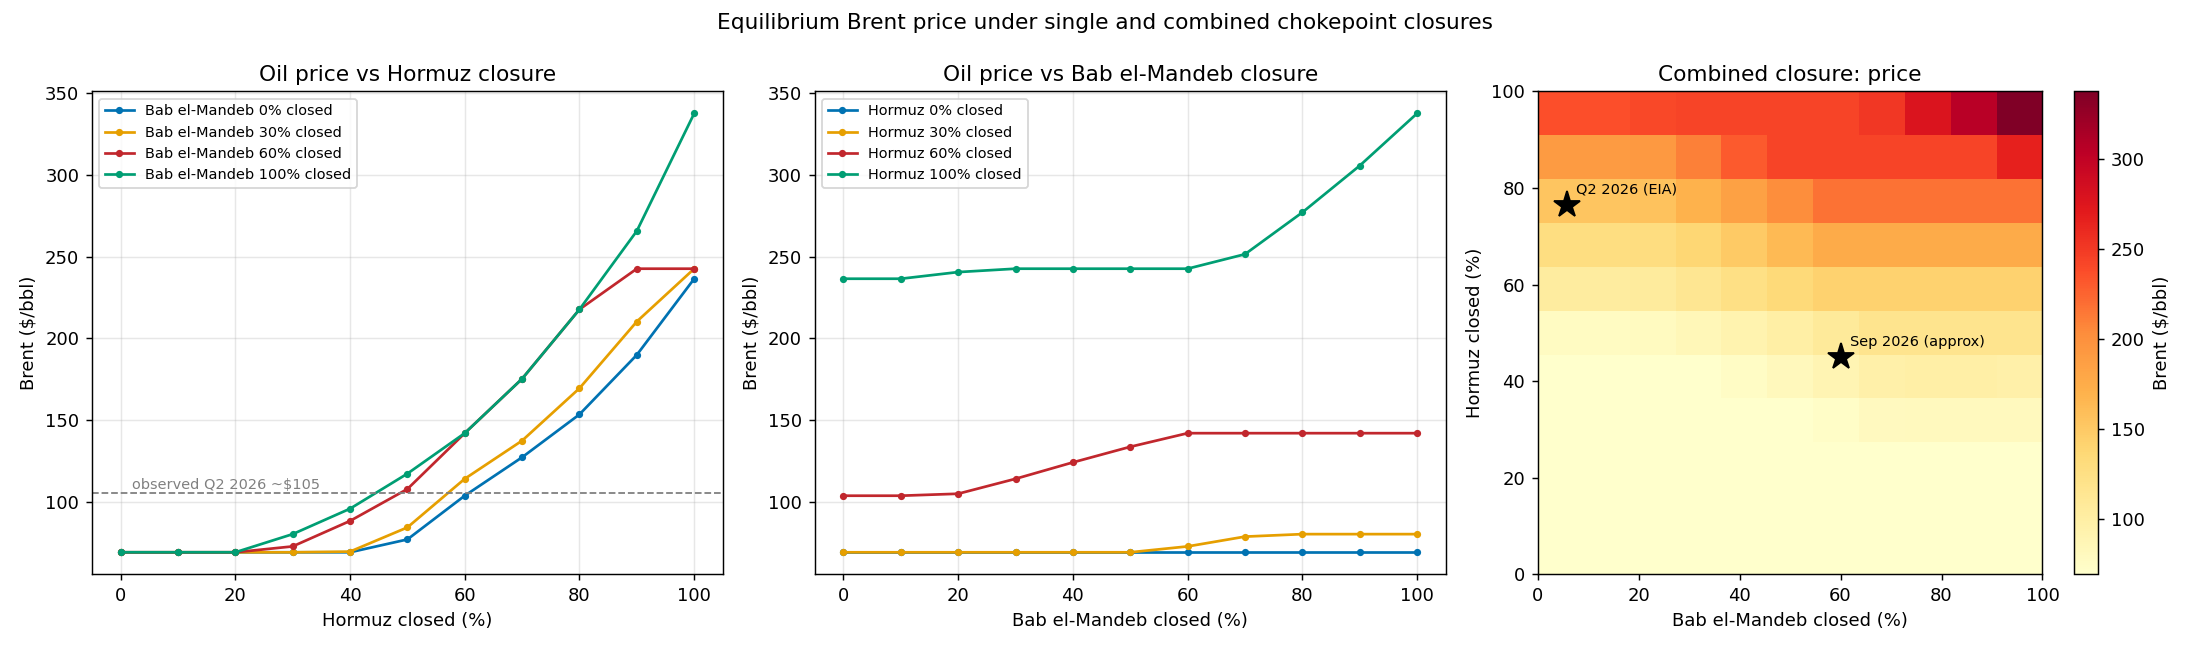

In [20]:
import closure_sensitivity as CS                     # the Hormuz x Bab el-Mandeb grid
for lab, pt in CS.REAL_POINTS.items():               # the two real 2026 operating points
    tot, by, brent = CS.steady_state(pt["hormuz"], pt["bab"])   # RUN the model at that combination
    obs = f"  (observed ${pt['brent']})" if pt["brent"] else ""
    print(f"{lab:<20} Hormuz {pt['hormuz']:.0%}  Bab {pt['bab']:.0%}"
          f"  ->  unserved {tot:5.2f} mb/d   Brent ${brent:4.0f}{obs}")

levels, U, P = CS.grid()                             # RUN 11 x 11 = 121 combinations (slow)
CS.plot_all(levels, U, P, out=FIG)                   # draw the damage and price charts into figures/
from IPython.display import Image, display
display(Image(f"{FIG}/closure_damage.png"))          # show them here
display(Image(f"{FIG}/closure_price.png"))

**Reading the closure charts.**

- **Hormuz drives the damage.** Unserved demand stays near zero until roughly half of
  Hormuz is closed — the bypass pipelines and alternative suppliers absorb it — then
  climbs steeply.
- **Bab el-Mandeb alone does little** — with Hormuz open, closing it barely registers.
- **Together they interact.** At 70% Hormuz closure, adding a full Bab el-Mandeb
  closure raises damage from 6.6 to 9.9 mb/d (+49%). The Saudi East-West pipeline is
  the main Hormuz bypass, but it exits through the Red Sea: **the bigger the bypass,
  the more the system depends on Bab el-Mandeb.** The safety valve and the
  vulnerability are the same route.
- **Price is strongly non-linear.** Because short-run demand is inelastic, each extra
  barrel of shortfall costs more than the last — the price surface curves sharply
  upward in the top-right corner.

## 9c. Extension (experimental): letting high prices spread the shortage

Section 4b showed the model's biggest limitation: demand cut by high prices is never
returned to the market. This extension (`src/experiment_feedback.py`) fixes it, **beside**
the main model rather than inside it:

- Each day every region cuts demand according to yesterday's price and its elasticity,
  but never by more than **20%** of its demand.
- The oil it no longer buys goes back into the routing, where others can buy it.
- A cut made because of price counts as **lost oil** in the production cascade, exactly
  like oil that never arrived: `oil_available = (demand − price cut − shortfall) / demand`.
- The price is set by the oil **available** to sell.

With every extension switched off, the code reproduces the main model exactly (checked).

                                 threshold  Brent    China OtherAsi JapanKor    India   Africa   Europe NAmerica


Main model                           53.1%    236      63%      33%      98%     100%     100%     100%     100%


With price feedback (cap 20%)        63.9%    259      81%      74%      92%      80%      80%      89%      94%

(full closure: share of its oil each region can actually use)


Robustness: cap 30% -> 63.9%,  cap 10% -> 69.1%


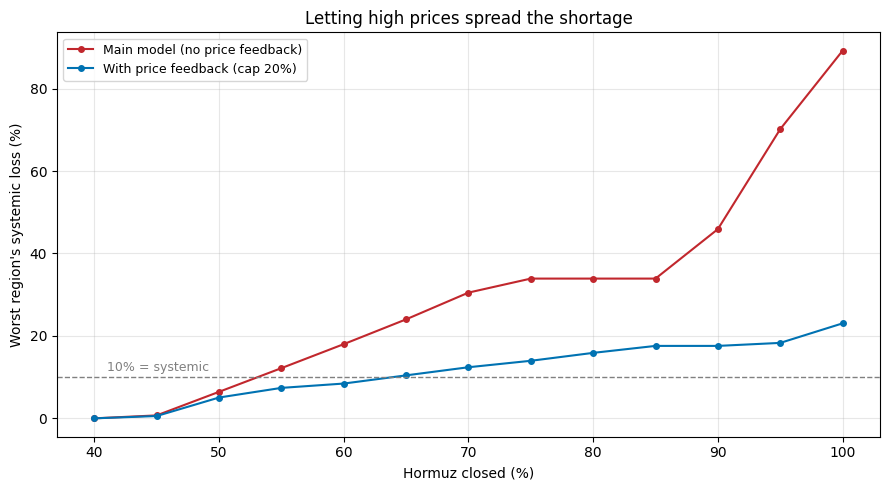

In [21]:
from experiment_feedback import run_experiment, threshold, plot_comparison

keys = ['China', 'OtherAsia', 'JapanKorea', 'India', 'Africa', 'Europe', 'NAmerica']
print(f"{'':32}{'threshold':>10}{'Brent':>7}" + ''.join(f'{k[:8]:>9}' for k in keys))
for lab, kw in [('Main model', {}), ('With price feedback (cap 20%)', dict(price_feedback=True))]:
    e = run_experiment(1.0, **kw)                    # RUN full closure, 150 days
    print(f"{lab:<32}{threshold(**kw):10.1%}{69*e['price']:7.0f}"
          + ''.join(f"{e['regions'][k]['oil_available']:9.0%}" for k in keys))   # share of oil each region can use
print("\n(full closure: share of its oil each region can actually use)")
print(f"Robustness: cap 30% -> {threshold(price_feedback=True, max_cut=0.30):.1%},"
      f"  cap 10% -> {threshold(price_feedback=True, max_cut=0.10):.1%}")

fig, path = plot_comparison(out=FIG)                  # worst-region loss vs closure, both versions
plt.show()

**Result.** With price feedback the threshold rises from **53% to 64%**, and the worst
region's loss at full closure falls from **89% to 23%**. The shortage is no longer dumped on
Asia: at about $259 every region cuts back — India and Africa to 80% of their oil, Europe
89%, China 81%, Other Asia 74%. The curve rises gently instead of steeply.

**Timing matters.** The 64% is measured after prices have had time to work. On day 1 the
shortage is still concentrated in Asia, exactly as in the main model; it takes about a month
for high prices to spread it. At 60% closure, for example, the worst region loses 18.6% on
day 1 and 11.6% on day 10 — still systemic — but only 8.3% by day 30. So the main model's
53% describes the **first weeks** of a closure, and the extension's 64% describes the
situation **once markets have adjusted**.

This is closer to what happened in 2026, when demand fell worldwide rather than only in
Asia. It suggests the main model's threshold is **pessimistic**: concentrating the whole
shortage on a few regions makes them fail sooner. The result is robust to the cap (20% or
30% gives 63.9%; a very tight 10% gives 69.1%), the Q2 2026 price is unchanged ($143
without reserves), and correcting Europe's demand to 13.9 mb/d changes nothing (53.1%
unchanged in the main model).

**Tried, not adopted.** Releasing every reserve onto the world market as extra supply gave
thresholds of 75–92% — but the worst region's loss stays close to 10% across a wide range
of closures, so tiny changes swing the threshold by ten points or more, and it interacted
oddly with the greedy bidding (Japan/Korea lost oil when reserves were added). Those
numbers are not reliable enough to report.

## 10. Findings, limitations and future work

**Findings**
1. **Critical blockade intensity ~53%** — the worst region first loses 10% of weighted
   output when 53% of Hormuz is blocked. An et al. (2026) report 32–46% on a different
   definition (50% terminal loss). The value is robust to the operability floor
   (52.6–53.1%) but moved 54% → 38% → 56% → 50% → 52% → 56% → 55% → 53% across structural
   revisions: it is **more sensitive to structural choices than to any parameter**.
2. **Which intervention raises the threshold most.** Per barrel, bypass capacity (+14
   points per ~3 mb/d) beats demand restraint (+7) and reserves (+5). In practice,
   realistic reserves raise it most (+19), but only until regional stocks run out (China's
   on day 350); bypass and restraint are permanent. All three together: +38.
3. **Damage is confined to high-Hormuz-exposure Asia.** At full closure Other Asia loses
   6.7 mb/d (67% of demand), China 6.0 (37%), Japan/Korea 0.1. Europe, India and North
   America are fully supplied.
4. **Correlated chokepoint failure raises damage by ~49%** — adding Bab el-Mandeb takes
   unserved demand from 6.6 to 9.9 mb/d at 70% Hormuz closure, because the main Hormuz
   bypass exits through the Red Sea.
5. **The model brackets the real 2026 price** — $94 with full reserves and $143 without at
   the Q2 2026 operating point; observed ~$105.
6. **Strategic reserves are in the wrong place** — at full closure, day 100, Brent is ~$236
   with no reserves, ~$151 with realistic regional reserves, ~$81 if pooled. About 500 Mb
   (US, Europe, India) is never drawn.
7. **The real network is more robust than random graphs** — removing its most central
   chokepoint costs 5.6% of capacity against 12–27% for ER, WS, BA and rewired graphs.
8. **Volatility matters** — oscillating disruption does ~31% more damage than a smooth
   ramp at identical total exposure; order alone makes no difference. The reason is not
   memory — each day starts afresh, which is why order doesn't matter — but that damage rises
   faster than closure: 30% closed costs nothing and 80% costs 8.5 mb/d, so swinging between
   them averages 4.26 against 3.26 for a steady ramp.

**A retracted finding.** An earlier version showed North America losing supply
through price contagion despite ~2.5% Hormuz exposure. That was an artefact:
production was entered as crude only (18.5 mb/d) while consumption was total
liquids. On a consistent total-liquids basis North America is a **net exporter**
(31.8 produced, 24.6 consumed) and is not exposed.

**Limitations**
- **Two price-calculation bugs were found and fixed** during the review: one price
  routine still used a linear demand form, and two simulations counted demand
  destruction twice, understating price. All price results now use a single
  constant-elasticity clearing function.
- **Validation is limited.** Hormuz flow is set from observation, so its agreement
  is not a test. The emergent downstream corridors under-predict observed 2026
  flows by roughly half: the model gets the direction of rerouting right but not
  the magnitude.
- **Greedy, single-pass allocation, not an equilibrium.** Each day routes are filled
  fastest-first and never revisited, so trade concentrates on short routes instead of
  spreading as freight on crowded routes rises. Long-term contracts, terminal capacity and
  sanctions discounts are not represented.
- **Route coverage is hand-built.** A review found the bypass pipelines had no routes to
  Japan/Korea or Other Asia; adding them moved the threshold from 52% to 56% and raised
  China's supply at full closure from 51% to 66%. Other gaps may remain.
- Under disruption the model sends 3.5 mb/d of crude-equivalent through Panama, the
  canal's limit; real crude transits are small because large tankers cannot fit.
- Emergent flows under-represent Suez, Bab el-Mandeb and Panama, which carry
  large volumes of refined products not modelled here. Allocation is a single
  greedy pass, not an equilibrium: it never spreads trade across corridors as
  rising freight on crowded routes would in a real market.
- Price has no risk premium or speculative component; the observed 2026 price falls
  inside the model's with/without-reserves bracket rather than being reproduced exactly.
- **Hoarding and redistribution friction are disabled by default.** Hoarding let
  inflated orders compete as real demand (Japan/Korea fell to 79% unserved);
  friction stranded domestic production. Both remain as switches.
- Open sea straits have no throughput limit, only a normal flow (EIA 2023); pipelines and
  canals do. The Suez and Panama limits are assumptions. A passage that is x% closed lets
  through (1 - x) of its normal flow - the same rule for Hormuz and Bab el-Mandeb.
- Refinery complexity enters only as a small (≤15%) efficiency uplift, not as
  explicit crude-grade matching.

- **Refinery-complexity uplift is a proxy.** The model credits complex refineries with up
  to 15% more usable product per barrel, as a stand-in for crude-grade matching that is
  not modelled. Removing it lowers the threshold from 53% to 51%.
- **No price feedback into routing.** Demand cut by high prices (section 4b) is never
  returned to the market: the routing uses full demand every day. So the physical shortage
  is concentrated in Asia, while at the clearing price every region would cut back and the
  freed oil would partly reach Asia. Damage in Asia is probably overstated. Fixing this
  would also require the production cascade to count price-destroyed demand as lost input,
  which changes what "systemic loss" measures - future work.
- **Bidding is greedy and static.** Bids are set once per day from the Stage 1 shortfall,
  and a single queue serves the highest netback first. Because freight differences are
  small next to differences in scarcity, netback makes no measurable difference: the most
  desperate region is served first.
- **Some regional consumption figures are estimates.** Middle East, Latin America,
  Africa and Other Asia consumption have no recorded source, and Europe's 14.5 mb/d is
  about 0.6 above the Energy Institute's 13.9. How every regional figure was obtained is
  set out in `data/DATA_AND_SOURCES.md`.
- **Data years are mixed.** Regional production uses 2025 figures and consumption 2024
  figures. That makes the global surplus about 3.3 mb/d (105.3 − 102.0), roughly double
  EIA's 2025 balance of about 1.6 (105.4 − 103.7). More spare oil makes the model slightly
  more resilient than reality, so the threshold is probably a little high.
- North America's production was corrected during review from 31.8 to EIA's 31.1 mb/d
  (US 23.1 + Canada 6.1 + Mexico 1.9, total liquids), moving the threshold from 55% to 53%.

**Future work.** Represent long-term supply contracts; split origins by export
terminal and field; add refined-product trade; model hoarding as inventory build
that moves price without inflating allocation demand; implement crude-grade
matching.